# From an SEM micrograph to a grinding simulation

### Measuring real abrasive grit, and predicting whether it cuts or fractures

---

This notebook takes one scanning-electron micrograph of abrasive grit and ends with a
verified Abaqus/Explicit deck that predicts **how** material is removed — by plastic
flow or by fracture — using a custom hybrid constitutive law.

Every stage runs here, in order, and shows its output. Nothing is asserted that is
not also drawn.

```
   SEM micrograph
        │
        ├─ 1  calibrate ............ pixel size from the instrument, cross-checked
        ├─ 2  segment .............. 12 image-processing stages, each one shown
        ├─ 3  measure .............. 25 shape descriptors per grain
        ├─ 4  reconstruct .......... each grain as a watertight 3-D solid
        │
        ├─ 5  assemble ............. grains onto a wheel, workpiece in contact
        ├─ 6  the physics .......... where removal stops being ductile
        ├─ 7  write the deck ....... Abaqus .inp + VUMAT subroutine
        ├─ 8  verify ............... independent gates on the written file
        └─ 9  results .............. what has been run, and what cannot yet be quoted
```

## The question this answers

A grinding wheel is not a cutting tool with a defined edge. It is thousands of
irregular, randomly-oriented abrasive grains, and what each one does to the workpiece
depends on how deep it happens to be cutting at that instant.

Below a **critical depth of cut $d_c$**, a brittle solid — rock, ceramic — is removed
by *plastic flow*, leaving a smooth, low-damage surface. Above $d_c$, it is removed by
*fracture*: chipping, subsurface cracks, a rough surface.

$$h < d_c \;\Rightarrow\; \text{ductile (Johnson–Cook + strain-gradient)} \qquad
  h \ge d_c \;\Rightarrow\; \text{brittle (Johnson–Holmquist II)}$$

A conventional simulation picks one law and applies it everywhere, so it can never show
the transition. **This one chooses per material point, from the chip thickness that
point actually sees.** That is the contribution.

## What is measured and what is modelled — stated up front

| | |
|---|---|
| **Measured** from the micrograph | grain outline, area, perimeter, Feret diameters, aspect ratio, circularity, solidity, corner angles — everything in-plane |
| **Modelled**, and flagged as such | grain *height* (a single top-down image cannot give it), seeded from the measured minimum Feret width |
| **From the literature** | JH-2 cards for both materials; hardness and fracture toughness |
| **Placeholder** — not yet calibrated | Johnson–Cook $B, n, C, m$ and $D_1..D_5$. Only $A$ is derived, so the two branches meet at the transition. **No force from this model should be quoted until these are calibrated.** |

> Units are **mm, tonne, s, MPa, N** throughout, and the wheel axis is **Z**.

---
*Run the cells in order. The whole notebook takes about three minutes and needs no
uploads — a real SEM image is embedded.*

---
# 0 · Setup

The entire `semgrit` package, both VUMAT subroutines, the verification gates and one
real SEM micrograph are embedded in the cell below. Nothing is downloaded; no
repository has to still exist.

In [1]:
#@title Run once — unpack the pipeline and check the environment
import base64, gzip, io, os, subprocess, sys, tarfile, time

PAYLOAD = (
    "..."
    "RwA="
)

WORK = "/content" if os.path.isdir("/content") else os.getcwd()
os.chdir(WORK)
with tarfile.open(fileobj=io.BytesIO(gzip.decompress(base64.b64decode(PAYLOAD)))) as tf:
    tf.extractall(WORK)
if WORK not in sys.path:
    sys.path.insert(0, WORK)

# mapbox_earcut is NOT preinstalled on Colab, and without it every grain fails to
# triangulate and the library comes out empty -- which looks like a segmentation
# problem and is not one. So it is checked for with the rest.
missing = []
for mod, pip in [("numpy", "numpy"), ("scipy", "scipy"), ("skimage", "scikit-image"),
                 ("cv2", "opencv-python-headless"), ("shapely", "shapely"),
                 ("PIL", "pillow"), ("mapbox_earcut", "mapbox-earcut"),
                 ("matplotlib", "matplotlib")]:
    try:
        __import__(mod)
    except ImportError:
        missing.append(pip)
if missing:
    print("installing:", " ".join(missing), "...")
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", *missing], check=True)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import PIL, cv2, shapely, skimage, mapbox_earcut          # noqa: F401

import semgrit
from semgrit import figures as F

SEM_IMAGE = os.path.join(WORK, "B4C_15.tif")
assert os.path.exists(SEM_IMAGE), "the embedded micrograph did not unpack"

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print("  working dir : %s" % WORK)
print("  python      : %s" % sys.version.split()[0])
print("  numpy %-8s matplotlib %-8s scikit-image %s"
      % (np.__version__, matplotlib.__version__, skimage.__version__))
print("  opencv %-7s shapely %-11s pillow %s"
      % (cv2.__version__, shapely.__version__, PIL.__version__))
print()
print("  semgrit modules      : %d"
      % len([f for f in os.listdir("semgrit") if f.endswith(".py")]))
print("  subroutines          : vumat_grind.for, vumat_grind2.for, vumat_jh2.for")
print("  verification gates   : 5")
print("  embedded micrograph  : %s  (%.0f kB)"
      % (os.path.basename(SEM_IMAGE), os.path.getsize(SEM_IMAGE) / 1e3))
print()
print("  ready.")

C:\Users\Akson\AppData\Local\Temp\ipykernel_26212\1199790192.py:19437: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(WORK)


ENVIRONMENT
  working dir : C:\malav parikh\sem-abaqus
  python      : 3.12.10
  numpy 2.4.2    matplotlib 3.10.9   scikit-image 0.26.0
  opencv 5.0.0   shapely 2.1.2       pillow 12.2.0

  semgrit modules      : 29
  subroutines          : vumat_grind.for, vumat_grind2.for, vumat_jh2.for
  verification gates   : 5
  embedded micrograph  : B4C_15.tif  (880 kB)

  ready.


---
# 1 · The micrograph, and the number everything scales with

The single most important number in the whole pipeline is the **pixel size**. Every
measured length is proportional to it, so every grain, and therefore the whole wheel,
scales with it.

It is read from the instrument's own metadata — Zeiss SmartSEM writes
`AP_IMAGE_PIXEL_SIZE` into TIFF tag 34118 — **not** from the burnt-in scale bar.

The scale bar is measured independently anyway, tick-centre to tick-centre, and its
label recovered by snapping to the nearest 1–2–5 value. That gives an OCR-free
cross-check. **If the two disagree by more than 5 %, the run stops** rather than
proceeding with a scale it cannot defend.

> **Why this is worth a section of its own.** The notebook this package replaced found
> the scale bar with a bright-object search, which locked onto the white databar strip —
> 1019 px instead of the 68 px bar. Every measurement in it was **14.9× too small at
> 10 kX and 29.9× too small at 5 kX**. A silently wrong calibration does not look like
> an error; it looks like a result.

CALIBRATION
  file                : B4C_15.tif
  full frame          : 1024 x 768 px
  databar detected at : row 695  (cropped off before measuring)
  micrograph          : 1024 x 695 px

  pixel size          : 0.05859 um/px      <- from metadata
  field of view       : 60.0 x 40.7 um
  magnification       : 5.00 K X

  scale bar found     : 34 px wide
  it therefore implies: 1.9921 um
  snapped to 1-2-5    : 2 um
  bar's pixel size    : 0.05882 um/px

  METADATA vs BAR     : +0.40 %   ->  AGREE (tolerance is 5 %)



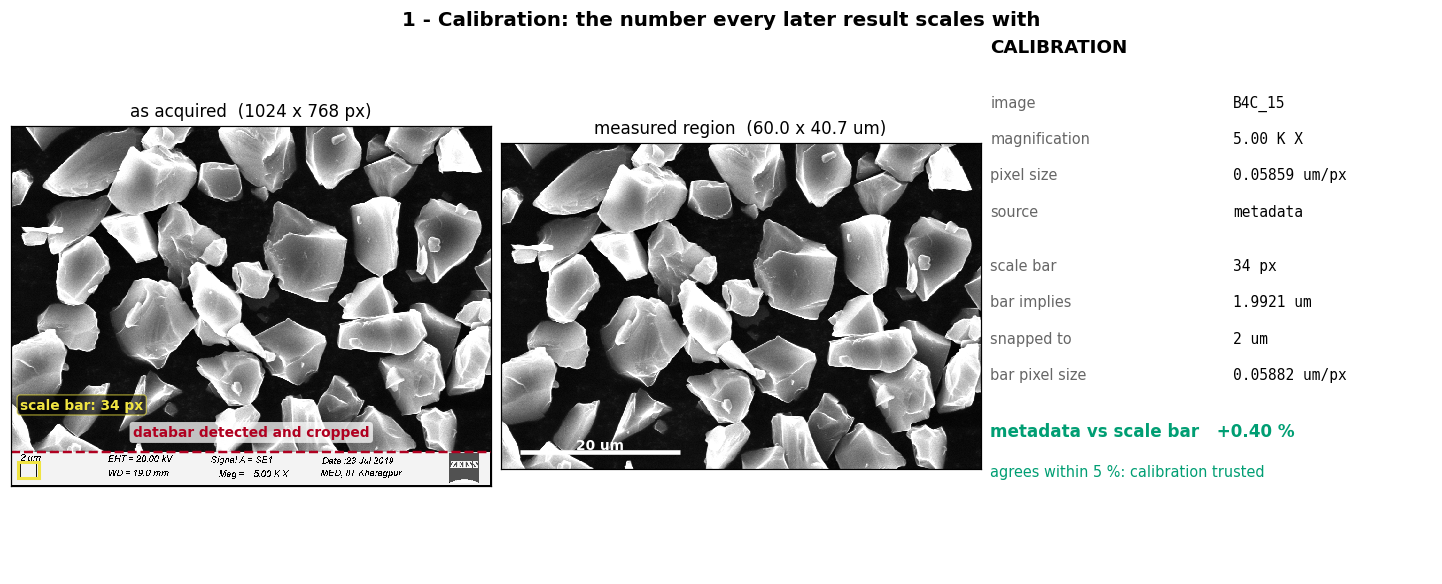

In [2]:
#@title 1 · Load the micrograph and calibrate it
from semgrit.metrology import load_sem_image

sem = load_sem_image(SEM_IMAGE)

print("=" * 72)
print("CALIBRATION")
print("=" * 72)
print("  file                : %s" % os.path.basename(SEM_IMAGE))
print("  full frame          : %d x %d px" % sem.full_intensity.shape[::-1])
print("  databar detected at : row %d  (cropped off before measuring)"
      % sem.databar_top)
print("  micrograph          : %d x %d px" % sem.intensity.shape[::-1])
print()
print("  pixel size          : %.5f um/px      <- from %s"
      % (sem.pixel_size_um, sem.pixel_size_source))
print("  field of view       : %.1f x %.1f um" % (sem.width_um, sem.height_um))
print("  magnification       : %s" % (sem.magnification or "not recorded"))
if sem.scale_bar is not None:
    b = sem.scale_bar
    print()
    print("  scale bar found     : %.0f px wide" % b.length_px)
    print("  it therefore implies: %.4f um" % (b.implied_um or 0))
    print("  snapped to 1-2-5    : %g um" % (b.snapped_label_um or 0))
    print("  bar's pixel size    : %.5f um/px" % (b.pixel_size_um or 0))
if sem.scalebar_agreement is not None:
    a = 100 * sem.scalebar_agreement
    print()
    print("  METADATA vs BAR     : %+.2f %%   ->  %s"
          % (a, "AGREE (tolerance is 5 %)" if abs(a) <= 5 else "DISAGREE"))
for w in sem.warnings:
    print("  warning             : %s" % w)
print()

fig = F.calibration({"sem": sem, "name": os.path.splitext(
    os.path.basename(SEM_IMAGE))[0]})
plt.show()

---
# 2 · Segmentation — all twelve stages

Finding the individual grains. This is where the original notebook was weakest, so
every intermediate is drawn rather than described.

| stage | what happens | why |
|---|---|---|
| 1–2 | median denoise | SEM shot noise breaks the watershed |
| 3 | multi-Otsu threshold | two thresholds, so the mid-grey grain flanks are not lost |
| 4–5 | close, open, fill holes | closes the pits inside grains that would seed false splits |
| 6 | Euclidean distance transform | distance to the nearest background pixel — peaks at grain centres |
| 7 | h-maxima seeds | a peak must rise `h` above its surroundings to count, which merges the ragged plateau of peaks inside one angular grain |
| 8 | Sobel gradient | where the real intensity edges are |
| 9 | elevation = −distance + gradient | basins at grain centres, ridges at the necks between touching grains, pulled onto visible edges |
| 10 | watershed | deliberately **over**-segments |
| 11 | split retention | each split is kept only if the image supports it |
| 12 | area filter | final labelled grains |

**Stage 11 is the one to look at.** The watershed splits too much on purpose; a split
then survives only if the dividing line lies on a real intensity edge (`edge_strength`)
**or** the two regions meet at a narrow neck (`neck_ratio`) — the signature of two
particles in contact. Everything else is a watershed artefact and is merged back.

The scatter plot draws that decision for every boundary, with both thresholds. It is an
argument, not an assertion.

> All thresholds are in **microns**, not pixels, so a 5 kX and a 10 kX image are treated
> identically. In the original they were in pixels, and the segmentation silently
> changed with magnification.

C:\malav parikh\sem-abaqus\semgrit\segment.py:392: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  fg = remove_small_holes(fg, hole_px)


SEGMENTATION
  captured 14 intermediate stages in 0.54 s

  thresholds (multi-Otsu) : 74, 176
  foreground              : 58.8 % of the frame
  distance transform max  : 4.56 um
  h-maxima seeds          : 53
  watershed regions       : 53   (over-segmented on purpose)

  shared boundaries       : 46
    kept   (image supports the split) : 41
    merged (it does not)              : 5

  rejected by area        : 3 too small, 0 too large
  FINAL GRAINS            : 45
    of which touch the frame edge : 18  (measured, but excluded from
                                       the size distribution)



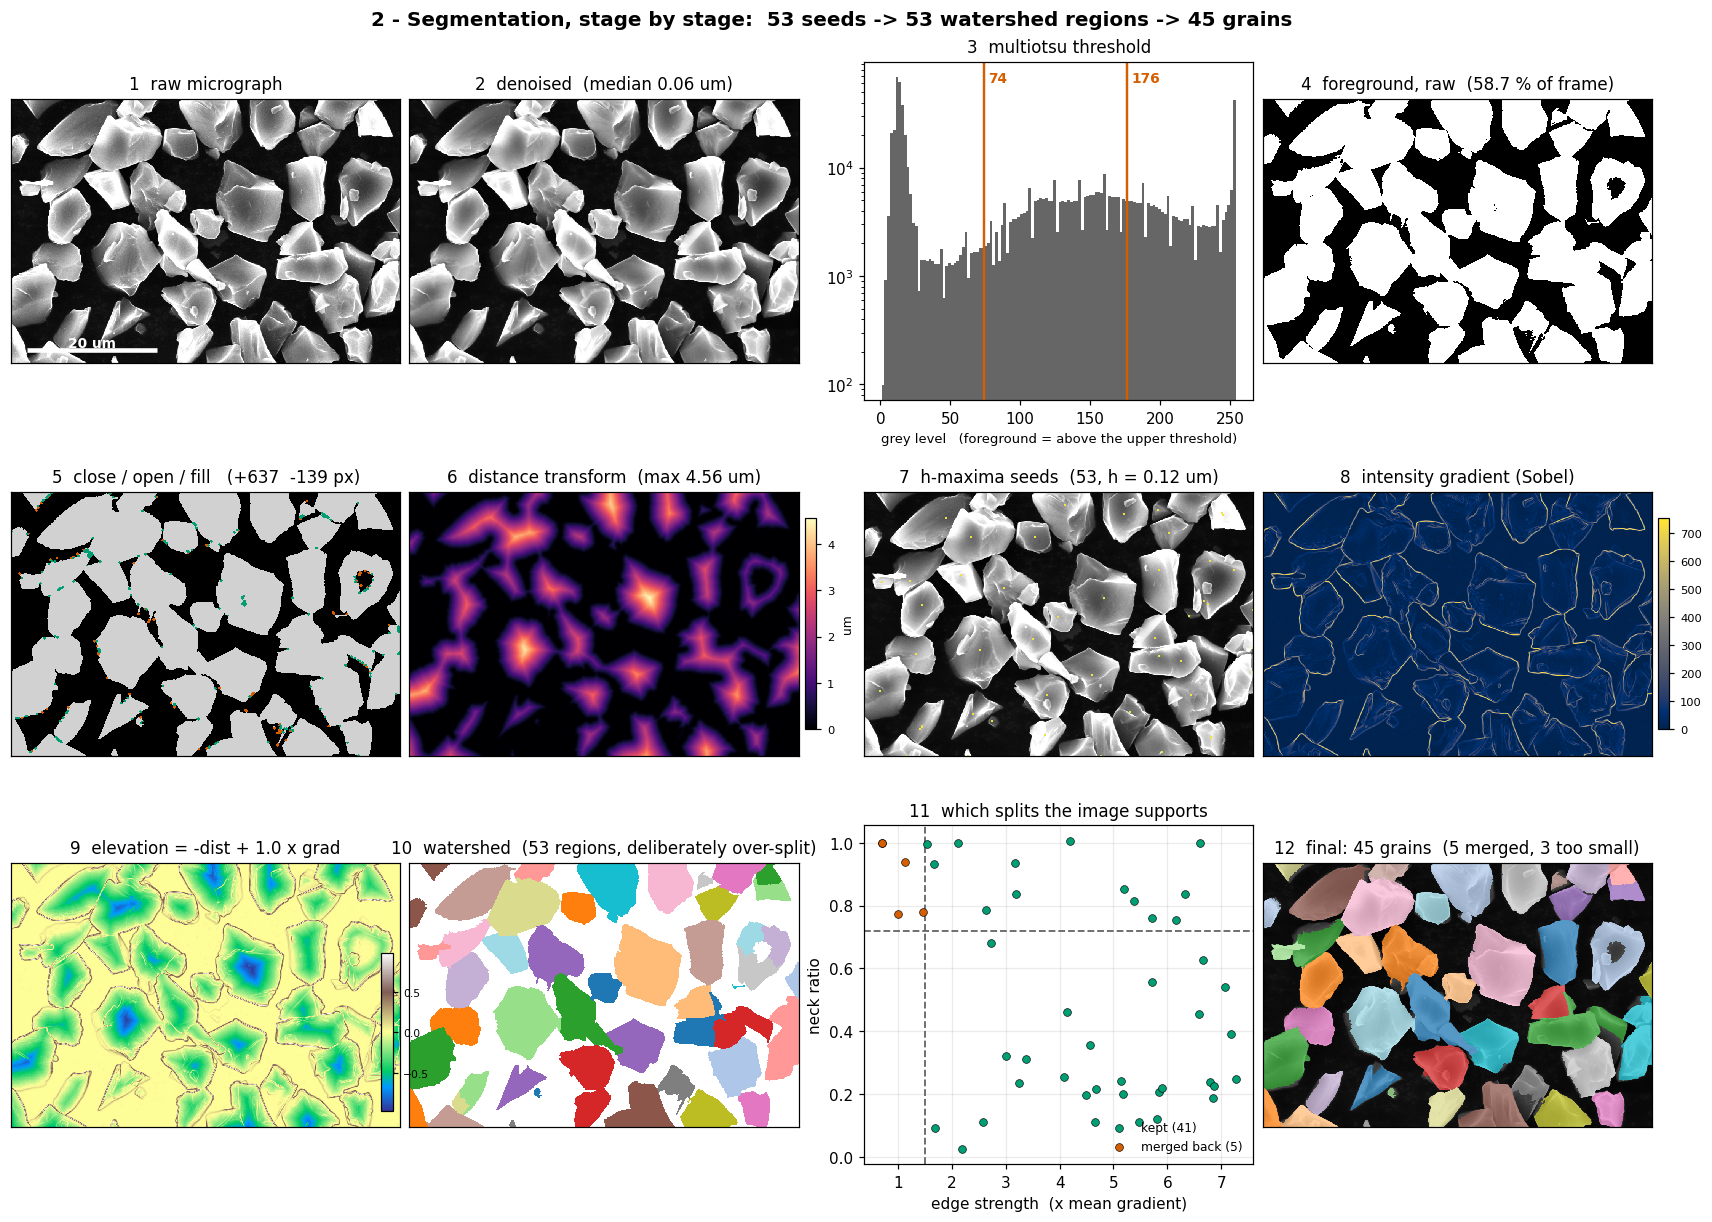

In [3]:
#@title 2 · Segment the grains, capturing every intermediate stage
from semgrit.segment import SegmentationParams, segment_grains, STAGE_KEYS

# The defaults, spelled out so the settings are visible rather than implied.
seg_params = SegmentationParams(
    median_um=0.06,        # denoise kernel
    min_grain_um=0.9,      # nothing smaller is a grain
    h_maxima_um=0.12,      # seed prominence
    gradient_weight=1.0,   # how hard the watershed is pulled onto real edges
    min_edge_strength=1.5, # a split needs an edge this many x the mean gradient
    min_neck_ratio=0.72,   # ... or a neck at least this narrow
    min_area_um2=0.7,
)

STAGES = {}
t0 = time.time()
seg = segment_grains(sem, seg_params, stages=STAGES)
dt = time.time() - t0

print("=" * 72)
print("SEGMENTATION")
print("=" * 72)
print("  captured %d intermediate stages in %.2f s" % (len(STAGES), dt))
print()
print("  thresholds (multi-Otsu) : %s"
      % ", ".join("%.0f" % t for t in seg.threshold_values))
print("  foreground              : %.1f %% of the frame"
      % (100.0 * seg.foreground.mean()))
print("  distance transform max  : %.2f um" % STAGES["distance_um"].max())
print("  h-maxima seeds          : %d" % seg.n_seeds)
print("  watershed regions       : %d   (over-segmented on purpose)"
      % STAGES["watershed_raw"].max())

ev = STAGES["boundary_evidence"]
kept = sum(1 for v in ev.values() if v["kept"])
print()
print("  shared boundaries       : %d" % len(ev))
print("    kept   (image supports the split) : %d" % kept)
print("    merged (it does not)              : %d" % (len(ev) - kept))
print()
print("  rejected by area        : %d too small, %d too large"
      % (seg.rejected["too_small"], seg.rejected["too_large"]))
print("  FINAL GRAINS            : %d" % seg.n_grains)
print("    of which touch the frame edge : %d  (measured, but excluded from"
      % len(seg.border_labels))
print("                                       the size distribution)")
print()

fig = F.segmentation_stages({"sem": sem, "seg": seg, "stages": STAGES})
plt.show()

---
# 3 · Measuring the grains

25 shape descriptors per grain, computed on the **actual outline** — never a convex
hull.

That distinction matters more than it sounds. The original pipeline simplified every
grain to a convex hull of 8–10 vertices. A convex hull fills in exactly the concave
notches that do the cutting, and inflates the measured size while doing it.

Two other things worth naming:

* **Perimeter** uses the Crofton estimator over 4 directions. Benchmarked against
  squares rotated 0–45°, that gives a mean error of −0.74 % and RMS 2.72 %, against
  5.15 % RMS for a traced contour. Circularity therefore still carries roughly **±10 %
  uncertainty on a single grain** — quoted here because it propagates.
* **Border-truncated grains are measured but excluded** from the distributions. They
  are real grains cut off by the frame, so their size is meaningless. In the original
  they were counted as whole, and they were 38–67 % of all regions.

MEASUREMENT
  descriptors per grain : 25
  grains measured       : 45
  border-truncated      : 18  (excluded from the distribution below)
  used for statistics   : 27

  areal density         : 11052 grains/mm2
  area coverage         : 41.2 % of the field

  descriptor                    d10      d50      d90      max
  ------------------------------------------------------------
  equivalent diameter um      3.758    6.491    9.251   10.665
  max Feret um                5.415    9.019   14.037   15.601
  min Feret um                3.062    5.957    8.557    9.928
  aspect ratio                1.257    1.415    2.157    2.348
  circularity                 0.375    0.684    0.764    0.908
  solidity                    0.744    0.909    0.951    0.970

  the five largest grains, as measured:
    id  area um2   d_eq um  Feret um  aspect    circ corners
  --------------------------------------------------------------
     1     89.33     10.67     13.99    1.42    0.76     15
     2    

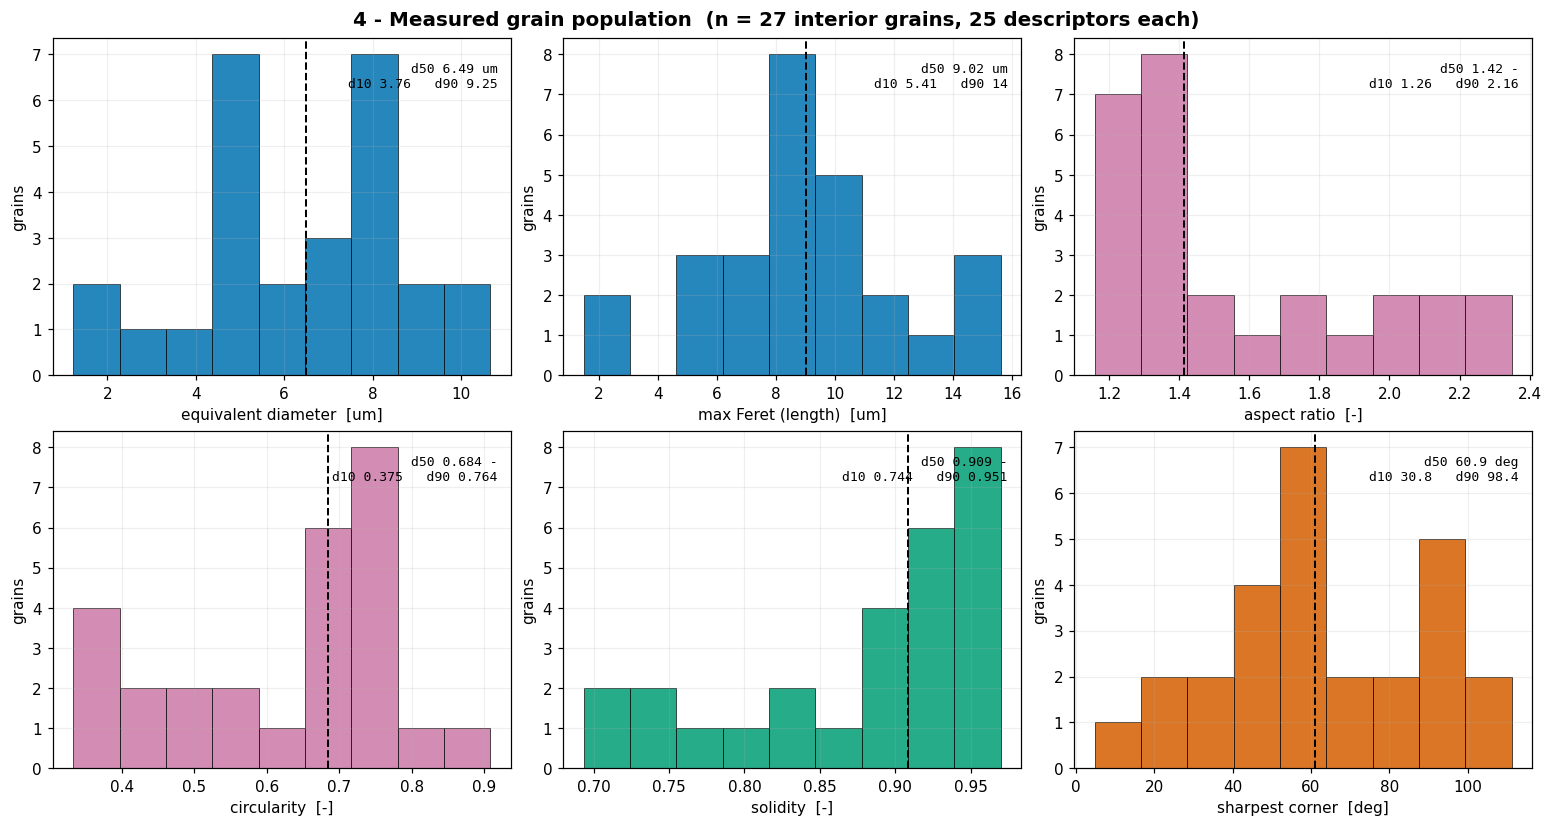

In [4]:
#@title 3 · Measure every grain, then show the population
from semgrit.measure import measure_all, grain_statistics, CSV_COLUMNS

grains = measure_all(seg, sem)
stats = grain_statistics(grains, sem, interior_only=True)

print("=" * 72)
print("MEASUREMENT")
print("=" * 72)
print("  descriptors per grain : %d" % len(CSV_COLUMNS))
print("  grains measured       : %d" % stats["n_grains_total"])
print("  border-truncated      : %d  (excluded from the distribution below)"
      % stats["n_grains_border"])
print("  used for statistics   : %d" % stats["n_grains_used"])
print()
print("  areal density         : %.0f grains/mm2" % stats["areal_density_per_mm2"])
print("  area coverage         : %.1f %% of the field"
      % (100 * stats["area_coverage_fraction"]))
print()
print("  %-24s %8s %8s %8s %8s" % ("descriptor", "d10", "d50", "d90", "max"))
print("  " + "-" * 60)
for key, label in [("equivalent_diameter_um", "equivalent diameter um"),
                   ("feret_max_um", "max Feret um"),
                   ("feret_min_um", "min Feret um"),
                   ("aspect_ratio", "aspect ratio"),
                   ("circularity", "circularity"),
                   ("solidity", "solidity")]:
    s = stats[key]
    if s.get("n"):
        print("  %-24s %8.3f %8.3f %8.3f %8.3f"
              % (label, s["d10"], s["d50"], s["d90"], s["max"]))

print()
print("  the five largest grains, as measured:")
print("  %4s %9s %9s %9s %7s %7s %6s"
      % ("id", "area um2", "d_eq um", "Feret um", "aspect", "circ", "corners"))
print("  " + "-" * 62)
for g in grains[:5]:
    print("  %4d %9.2f %9.2f %9.2f %7.2f %7.2f %6d"
          % (g.grain_id, g.area_um2, g.equivalent_diameter_um, g.feret_max_um,
             g.aspect_ratio, g.circularity, g.n_corners))
print()

fig = F.measurement_distributions(grains)
plt.show()

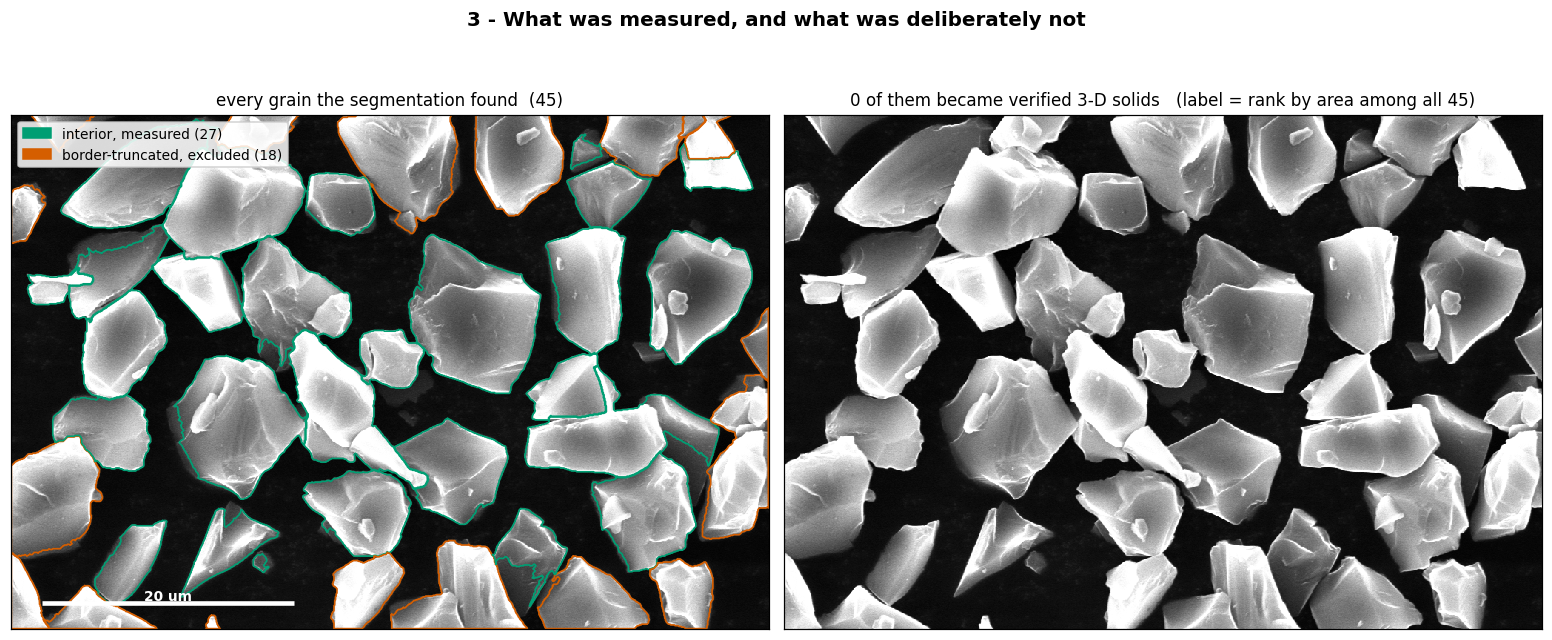

In [5]:
#@title 3b · What the segmentation kept, and what it deliberately did not
fig = F.segmentation_overlay({"sem": sem, "seg": seg, "grains": grains,
                              "solids": [], "stages": STAGES})
plt.show()

---
# 4 · Each grain as a watertight 3-D solid

The measured 2-D silhouette is lofted into a 3-D polyhedron: the outline at mid-height,
tapering to smaller faces above and below.

**Grain height is the one modelled quantity in the whole pipeline.** A single top-down
SEM image physically cannot give it. It is drawn from a seeded truncated normal on the
measured *minimum Feret width* (mean ratio 0.70, sd 0.12, clipped to [0.45, 0.95]),
representing blocky crushed grit. Seeded, so the same image always gives the same
wheel.

Tetrahedral meshing needs no extra dependency: the outline is ear-clipped, each triangle
swept into a prism, each prism split into 3 tets by a globally sorted vertex rule that
keeps shared diagonals — and therefore the mesh — conforming.

**Every solid is verified against closed-form geometry before it is allowed into the
library**, and a grain that fails any check is rejected rather than quietly shipped:

* mesh volume against the analytic prismatoid sum,
* maximum projected cross-section against the measured outline,
* closed surface — every edge used exactly twice,
* volume by the divergence theorem over the surface, against the tet sum,
* no inverted tets, no unused vertices, no facet reusing a node.

3-D RECONSTRUCTION
  interior grains offered : 27
  solids built and passed : 27
  rejected                : 0
  built in                : 0.2 s

  WORST CASE ACROSS EVERY SOLID
    mesh volume vs closed-form analytic volume : 3.62e-16 relative
    projected section vs measured outline      : 2.85e-02 relative
    (both are gates -- a solid that misses them is not shipped)

  grain library : 27 solids
    height um   : d10 2.11  d50 3.51  d90 6.41  max 7.05
    width  um   : d10 5.10  d50 7.91  d90 12.48  max 15.35
    faces/grain : 44 to 194
    tets/grain  : 36 to 186



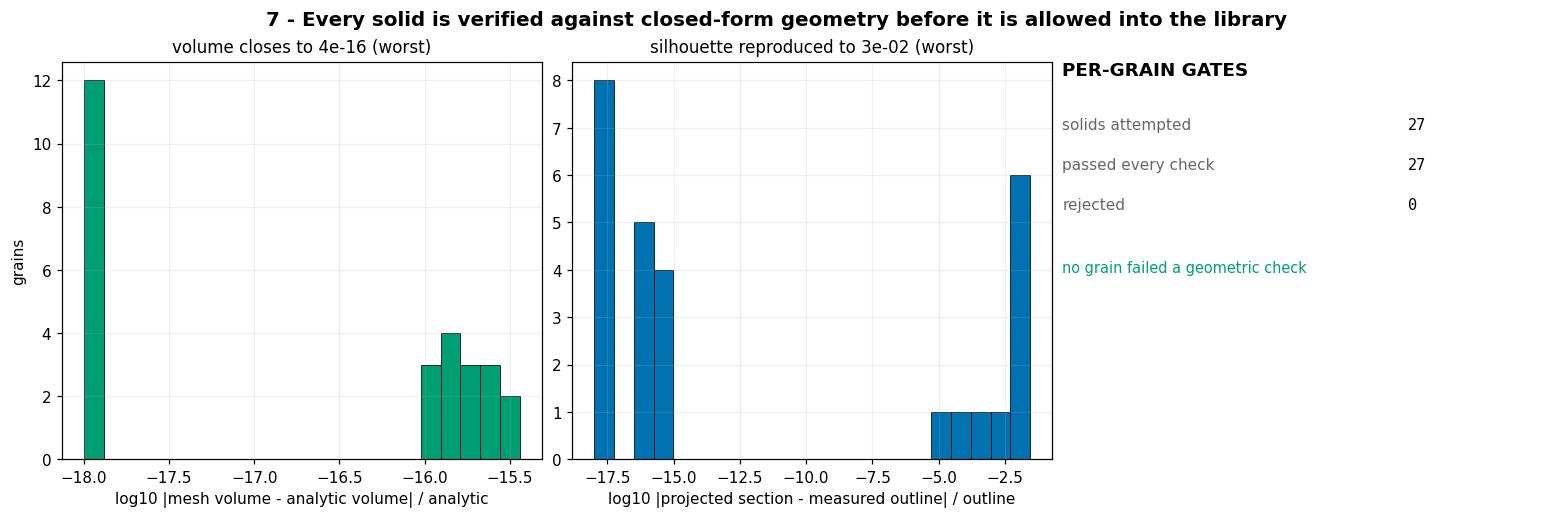

In [6]:
#@title 4 · Build the 3-D grain library, verifying every solid
from semgrit.grain3d import HeightModel, LoftProfile, build_grain_library

height_model = HeightModel(mean_ratio=0.70, std_ratio=0.12,
                           min_ratio=0.45, max_ratio=0.95, seed=20260728)
profile = LoftProfile(base_scale=0.70, mid_height_fraction=0.42, top_scale=0.30)

t0 = time.time()
solids, reports = build_grain_library(
    grains, seg, sem, height_model=height_model, profile=profile,
    simplify_um=0.10, max_vertices=64, interior_only=True)
dt = time.time() - t0

good = [r for r in reports if r.get("ok")]
bad = [r for r in reports if not r.get("ok")]

print("=" * 72)
print("3-D RECONSTRUCTION")
print("=" * 72)
print("  interior grains offered : %d" % len(reports))
print("  solids built and passed : %d" % len(good))
print("  rejected                : %d" % len(bad))
print("  built in                : %.1f s" % dt)
print()
if good:
    vre = max(abs(r["volume_rel_error"]) for r in good)
    are = max(abs(r["projected_area_rel_error"]) for r in good)
    print("  WORST CASE ACROSS EVERY SOLID")
    print("    mesh volume vs closed-form analytic volume : %.2e relative" % vre)
    print("    projected section vs measured outline      : %.2e relative" % are)
    print("    (both are gates -- a solid that misses them is not shipped)")
if bad:
    import collections
    print()
    print("  why the rejected ones were rejected:")
    for msg, n in collections.Counter(
            "; ".join(r.get("issues", ["?"])) for r in bad).most_common(5):
        print("    %3d  %s" % (n, msg[:60]))
print()
print("  grain library : %d solids" % len(solids))
h = np.sort([s.height_um for s in solids])
w = np.sort([max(s.extent_um()[:2]) for s in solids])
print("    height um   : d10 %.2f  d50 %.2f  d90 %.2f  max %.2f"
      % (np.percentile(h, 10), np.percentile(h, 50), np.percentile(h, 90), h.max()))
print("    width  um   : d10 %.2f  d50 %.2f  d90 %.2f  max %.2f"
      % (np.percentile(w, 10), np.percentile(w, 50), np.percentile(w, 90), w.max()))
print("    faces/grain : %d to %d"
      % (min(len(s.faces) for s in solids), max(len(s.faces) for s in solids)))
print("    tets/grain  : %d to %d"
      % (min(len(s.tets) for s in solids), max(len(s.tets) for s in solids)))
print()

REC = {"sem": sem, "seg": seg, "stages": STAGES, "grains": grains,
       "solids": solids, "reports": reports,
       "name": os.path.splitext(os.path.basename(SEM_IMAGE))[0]}

fig = F.solid_verification(REC)
plt.show()

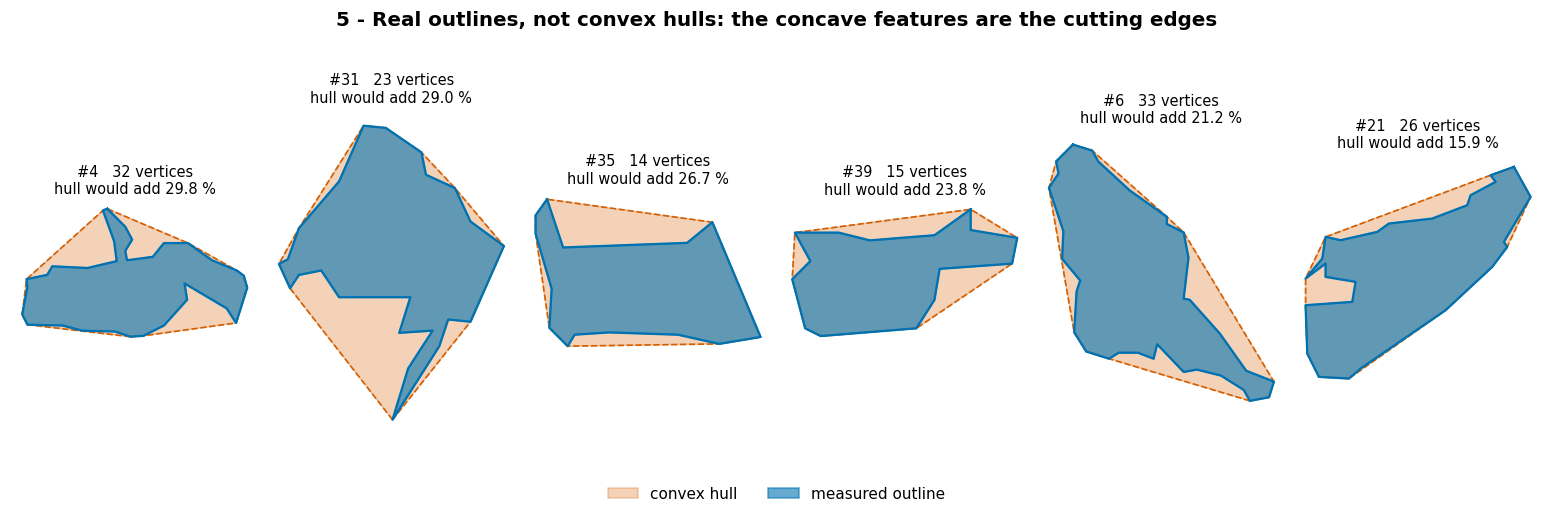

In [7]:
#@title 4b · Real outlines against convex hulls — what hulling would erase
fig = F.outline_fidelity(REC)
plt.show()

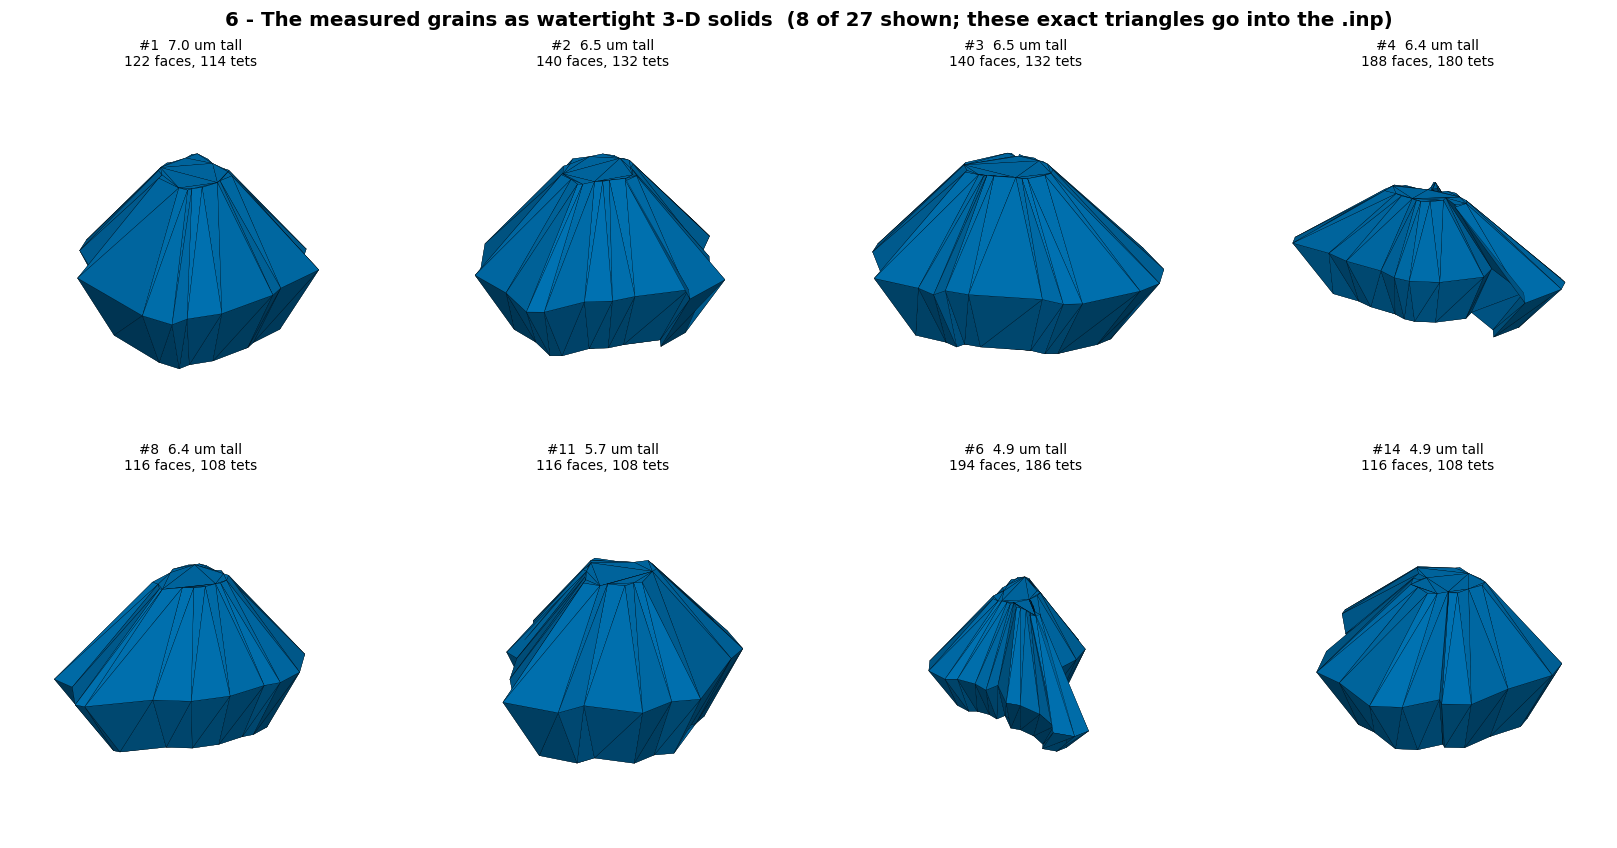

In [8]:
#@title 4c · The grains themselves, as they go into the deck
fig = F.grain_gallery(solids, n=8)
plt.show()

---
# 5 · Assembling the wheel, and seating the workpiece

The measured grains are seated onto a wheel sector. Three decisions are worth stating,
because each was a failure mode first:

**The whole wheel is one discrete rigid body.** Bond rim and every grit merged into a
single part, tied to **one** reference node on the axis. So the wheel is driven by one
boundary condition, and the bond contributes nothing to the stable time increment. The
alternative — one rigid body per grit — meant constraining hundreds of independent
reference nodes.

**Grains cannot interpenetrate.** Positions come from jittered-grid sampling whose cell
size *guarantees* the minimum separation, then audited by KD-tree. In the original they
were placed freely and overlapped.

**The workpiece is seated tangent to the tallest grit that can actually reach it** —
not to the globally tallest grain, which is typically a millimetre away and would leave
everything clear of the surface so nothing cuts. The footprint test clips each grit
facet to the block extent before taking its radial reach, because a facet can cross the
footprint edge between two vertices.

Coordinates are written to 12 significant figures. At a 25 mm radius that is a quantum
of ~2.5 × 10⁻¹¹ mm; the earlier 9-figure format left 10⁻⁸ mm, which was enough to push
grit facets through a face placed exactly tangent.

THE MODEL  (planned, not yet written)
WHEEL      50.0 mm diameter, 4.584 deg sector, rim 0.012 mm, 0.030 mm thick
           arc 2.000 mm, sagitta 20.0 um = 1.0% of the chord -> reads as an arc
GRITS      1 placed, 2500/mm2, dressed band 1.982 x 0.012 mm
           stand proud of the bond by 4.060 to 4.060 um (mean 4.060, median 4.060)
           grain height as measured 7.045 to 7.045 um (mean 7.045)
WORKPIECE  0.048 x 0.02 x 0.006 mm at theta = 2.292 deg, 612,480 C3D8R
           placed 'centred': spans theta 2.347 (entry) to 2.237 deg, over 1 grain
           grit occupies theta 2.326 to 2.326 deg (2.338 to 2.338 within the block's width)
           the surface travels toward decreasing theta, so grains arrive from the high-theta end
           grains under it stand 4.060 to 4.060 um proud; standoff set to 0.000 um
           mesh 0.15 cutting x 0.15 axial x 0.02-1.52 depth um
           ground face r = 25.004055 mm, tangent, bond clearance 4.055 um
ENGAGEMENT ae for 1 / 10 / 50 gri

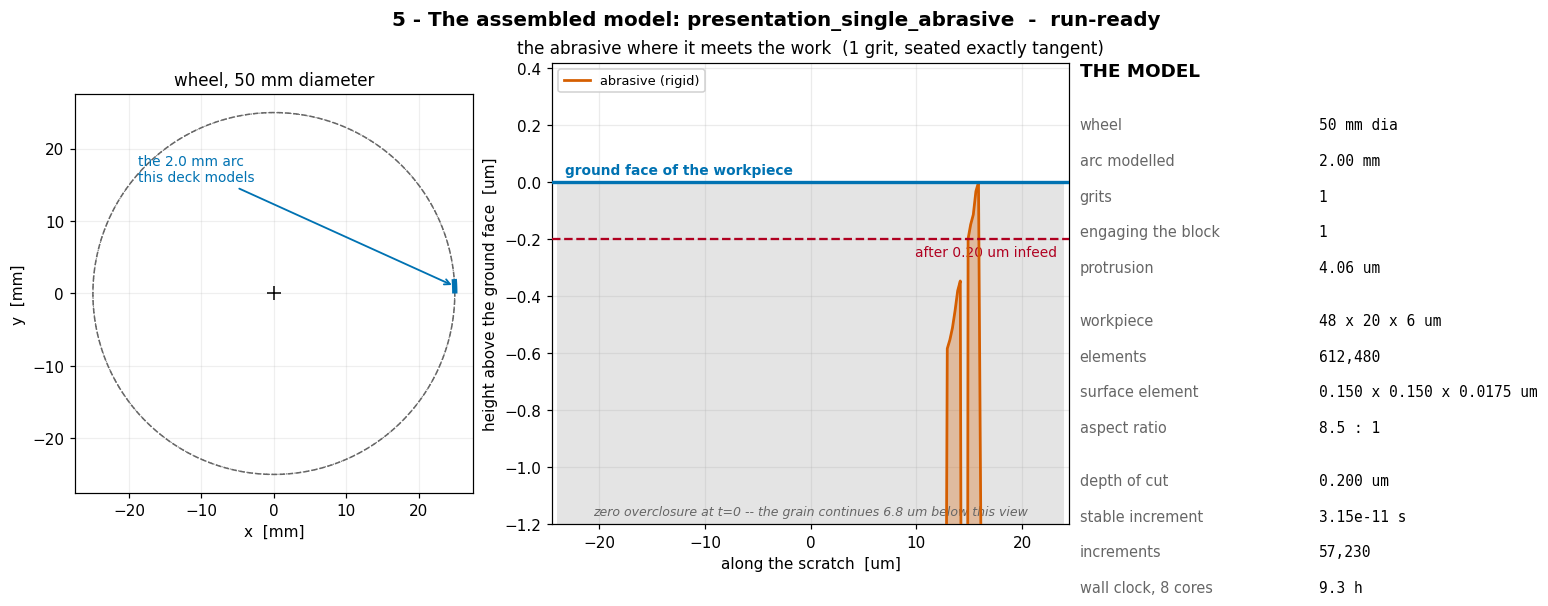

In [9]:
#@title 5 · Plan the wheel and the workpiece — nothing is written yet
from semgrit import materials
from semgrit.analysis import AnalysisParams
from semgrit.build_deck import DeckParams, plan_deck
from semgrit.hybrid import HYBRID_DEPVAR
from semgrit.preview import preview, summary_text

MATERIAL = "sandstone"     #@param ["sandstone", "silicon_carbide"]

# The ductile constants, hardness and toughness for the chosen material. dc_form
# 2 is Bifano's, the calibrated one -- form 1 gives 5.3 nm on this rock, which is
# honest physics and below anything a mesh can resolve, so it would show nothing.
HP = materials.hybrid_params(MATERIAL, h_source=0, dc_form=2)
DC_MM = HP.critical_depth_mm()

# THE DEPTH ELEMENT IS DERIVED FROM dc, not hardcoded. Five elements across dc is
# the smallest number that puts one element wholly inside the ductile zone, one
# wholly outside and one straddling; below about four the transition is an
# artefact of where the element boundary happens to fall.
ELEMENTS_PER_DC = 5.0
ELEMENT_DEPTH_MM = DC_MM / ELEMENTS_PER_DC

# One grit against a deformable block: the configuration the hybrid law is
# derived for, where the trajectory -- and therefore the chip thickness -- is
# known in closed form. Multi-grit decks sweep the field per element instead.
PARAMS = DeckParams(
    name="presentation_single_abrasive",
    diameter_mm=50.0,
    sector_mode="arc", arc_length_mm=2.0,
    rim_depth_mm=0.012, width_mm=0.030,
    include_bond=False,        # one grit and the workpiece, nothing else
    grit_mode="single", single_grain_index=-1,   # -1 = the largest measured grain
    single_grit_offset_mm=0.015,
    include_workpiece=True,
    wp_length_mm=0.048, wp_width_mm=0.020, wp_depth_mm=0.006,
    wp_element_size_length_mm=0.00015,
    wp_element_size_width_mm=0.00015,
    wp_element_size_depth_mm=ELEMENT_DEPTH_MM,
    wp_surface_layer_mm=0.00035, wp_depth_growth=1.45,
    wp_width_band_mm=0.006, wp_width_growth=1.35,
    clearance_um=0.0,          # tallest reachable grain exactly touching
    wp_position="centred",
    surface_speed_mm_s=30_000.0,          # 30 m/s at r = 25 mm
    cores=8,
    analysis=AnalysisParams(enabled=True, depth_of_cut_um=0.20,
                            material_model="hybrid", hybrid=HP,
                            n_depvar=HYBRID_DEPVAR, element_deletion=True),
)
# Moves the JH-2 card, the density and the *Material name together. Setting two
# of the three by hand is how a deck ends up silently mixing two materials.
materials.apply(PARAMS, MATERIAL)

PLAN = plan_deck(PARAMS, solids)

print("=" * 72)
print("THE MODEL  (planned, not yet written)")
print("=" * 72)
print(summary_text(PLAN))
print()

# semgrit.preview.preview() is the general-purpose four-panel view and is the
# right tool for a dressed multi-grit band. On this ONE-grit deck two of its
# panels degenerate to a single point, so the presentation figure is used here.
fig = F.assembly(PLAN)
plt.show()

---
# 6 · The physics: where removal stops being ductile

This is the section the whole project exists for.

## The two laws

$$h < d_c: \quad \sigma_e = \sigma_{JC}\sqrt{1 + \left(\frac{r'\,\eta\, b\,(M\alpha G)^2}
{\sigma_{JC}^2}\right)^{\Lambda}}, \qquad \eta = \frac{4\varepsilon_p}{h}$$

Johnson–Cook flow with a **strain-gradient enhancement** from the Taylor/GND hardening
of Yadav et al. (IJMS 2022 eq. 8; IJMTM 2024 eq. 25; IJMS 2026 eq. 7).

Thin cuts raise the strain gradient, which raises the flow stress. **That size effect is
*why* thin cuts are ductile** — without it the Johnson–Cook branch would understate the
ductile regime badly. The gradient length is floored at the Burgers vector, or
$h \to 0$ in the rubbing zone returns an infinite flow stress.

$$h \ge d_c: \quad \text{Johnson–Holmquist II}$$

Pressure-dependent strength surface, damage accumulation, bulking, `SFMAX`-capped
fractured strength. Verified against the JH94 bulking benchmark to **1.3 %**.

## How the subroutine learns $h$

A VUMAT sees no kinematics — it gets a strain increment and must return a stress. With
one grit the trajectory is exact, so $h$ is a closed-form function of position:

$$h(u) = H_0 + H_G u - \frac{u^2}{2R_{tip}}, \qquad H_G = -\frac{v_r}{v_s}$$

The linear term is the rubbing → ploughing → shearing wedge. The quadratic term is the
**sagitta** of the grit's circular path: ~15 nm over a 48 µm block on a 50 mm wheel,
which would be ignorable except that $d_c$ is of the same order.

$H_0$, $H_G$ and $R_{tip}$ are computed **in Python** and written into the material
card, so the Fortran carries no knowledge of wheels, infeeds or rotation senses — which
is what keeps it verifiable on a single material point.

## The honest part: $d_c$ has three definitions

| form | expression | on sandstone |
|---|---|---|
| 1 | $\lambda_c (H/E)^{1/2}(K_c/H)^2$ | 5.3 nm |
| 2 — Bifano, Dow & Scattergood (1991) | $\lambda_c (E/H)(K_c/H)^2$ | 87.8 nm |
| energy, pointwise | $W_p L_c \ge \Psi K_c^2/E$ | calibrated to match |

Forms 1 and 2 differ by $(E/H)^{3/2}$ — about **17×** on this rock. **$\lambda_c$
belongs to one form and is not transferable to the other**, so which one was used has
to be stated with any result. These decks use form 2, the calibrated one.

MATERIALS AVAILABLE

  Sandstone (JH-2, the project's original card)
    JH-2 K1     3736  G     2686  HEL    1982  PHEL   1374  T     8  MPa
    density   2350 kg/m3   hardness H   1000 MPa   toughness Kc 0.30 MPa.m^0.5
    quasi-static UCS from its own JH-2 card : 90.0 MPa
      -> this is what Johnson-Cook A is set to, so the ductile and
         brittle branches meet at the transition instead of stepping
    critical depth dc :  form 1     5.30 nm     form 2    87.75 nm
                         (they differ by 17x -- lambda_c is NOT shared)

  Silicon carbide, SiC-N (supplied as 'monocrystalline silicon')
    JH-2 K1   204785  G   183000  HEL   14457  PHEL   5900  T   370  MPa
    density   3163 kg/m3   hardness H  25000 MPa   toughness Kc 3.50 MPa.m^0.5
    quasi-static UCS from its own JH-2 card : 8004.2 MPa
      -> this is what Johnson-Cook A is set to, so the ductile and
         brittle branches meet at the transition instead of stepping
    critical depth dc :  form 1     0.

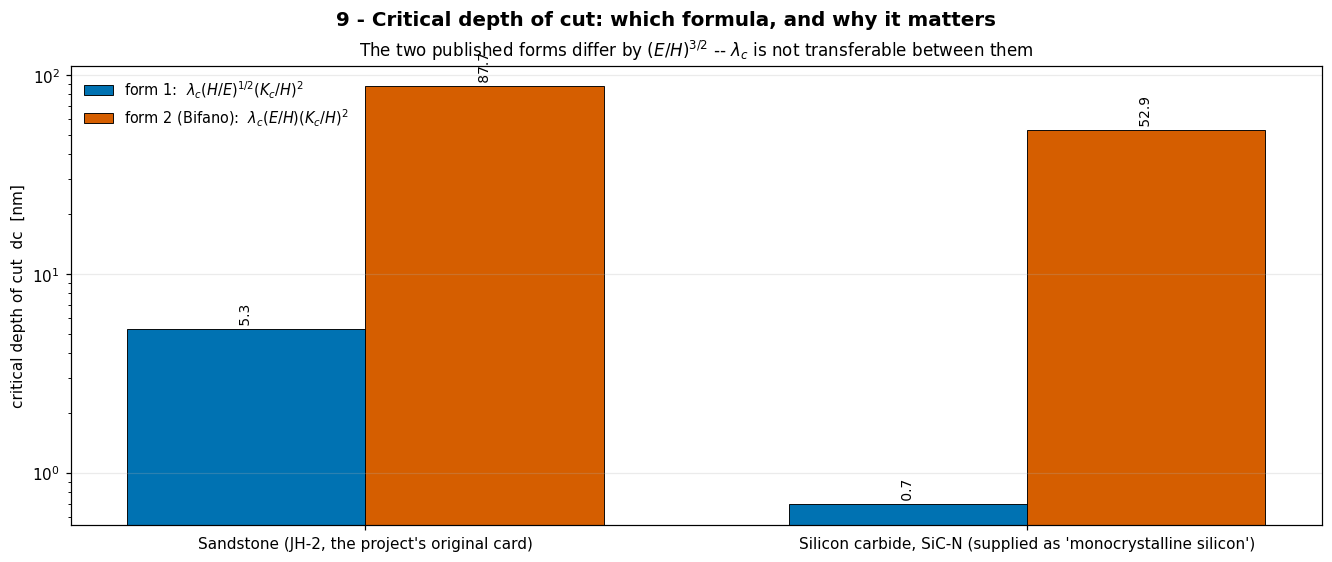

In [10]:
#@title 6 · The material, its critical depth, and the two published forms
from semgrit.materials import MATERIALS, hybrid_params, quasi_static_ucs_mpa

print("=" * 72)
print("MATERIALS AVAILABLE")
print("=" * 72)
for key, mat in MATERIALS.items():
    print()
    print("  %s" % mat.label)
    print("    JH-2 K1 %8.0f  G %8.0f  HEL %7.0f  PHEL %6.0f  T %5.0f  MPa"
          % (mat.jh2[0], mat.jh2[1], mat.jh2[2], mat.jh2[3], mat.jh2[4]))
    print("    density %6.0f kg/m3   hardness H %6.0f MPa   toughness Kc %.2f MPa.m^0.5"
          % (mat.density_kg_m3, mat.dc["hardness_mpa"], mat.dc["kic_mpa_sqrt_m"]))
    print("    quasi-static UCS from its own JH-2 card : %.1f MPa"
          % quasi_static_ucs_mpa(mat.jh2))
    print("      -> this is what Johnson-Cook A is set to, so the ductile and")
    print("         brittle branches meet at the transition instead of stepping")
    print("    critical depth dc :  form 1 %8.2f nm     form 2 %8.2f nm"
          % (mat.dc_nm(1), mat.dc_nm(2)))
    print("                         (they differ by %.0fx -- lambda_c is NOT shared)"
          % (mat.dc_nm(2) / max(mat.dc_nm(1), 1e-9)))

print()
fig = F.dc_forms(MATERIALS)
plt.show()

THE DUCTILE / BRITTLE SWITCH
  material          : Sandstone (JH-2, the project's original card)
  dc (form 2)       : 87.75 nm
  depth of cut ae   : 200 nm  = 2.3 x dc

  the card carries four numbers, and the Fortran needs nothing else:
    H0    = +6.403199e-05 mm     chip thickness at the block centre
    HG    = -3.703102e-03        wedge slope, = -v_r / v_s
    RTIP  = +2.500406e+01 mm     grit tip radius (sets the sagitta)
    THETA = +4.000000e-02 rad    the frame the field is written in

  h at block entry  :     0.00 nm
  h at block exit   :   141.39 nm
  TRANSITION        : u = -6.643 um along the scratch
                      -- this is the number the model exists to predict

  mesh check: the depth element must resolve dc, or the transition can
  only be located as well as the element that straddles it.
    depth element   : 0.0175 um
    elements per dc : 5.00



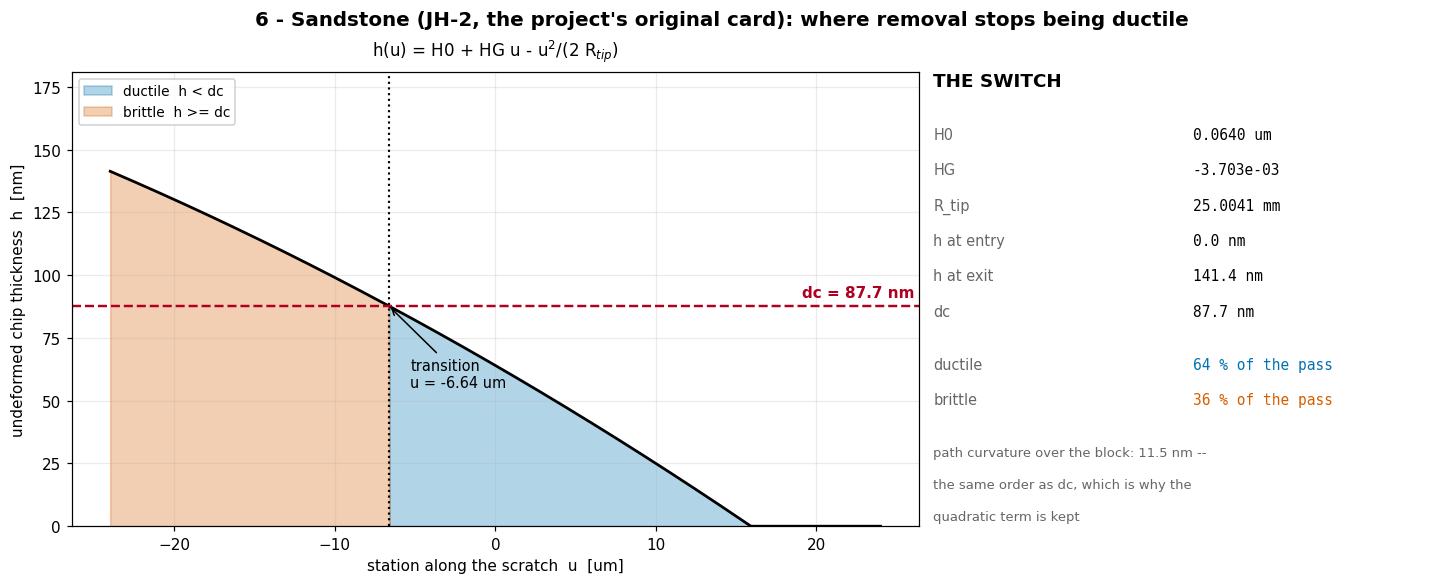

In [11]:
#@title 6b · The chip thickness this deck produces, against dc
from semgrit.hybrid import plan_hybrid

# MATERIAL, HP and PLAN were set in section 5, so the field drawn here is the
# field of the deck that section planned -- not a re-derivation that could
# quietly disagree with it.
FIELD, DC_MM = plan_hybrid(PLAN, HP)

print("=" * 72)
print("THE DUCTILE / BRITTLE SWITCH")
print("=" * 72)
print("  material          : %s" % MATERIALS[MATERIAL].label)
print("  dc (form 2)       : %.2f nm" % (DC_MM * 1e6))
print("  depth of cut ae   : %.0f nm  = %.1f x dc"
      % (PARAMS.analysis.depth_of_cut_um * 1000,
         PARAMS.analysis.depth_of_cut_um / 1000 / DC_MM))
print()
print("  the card carries four numbers, and the Fortran needs nothing else:")
print("    H0    = %+.6e mm     chip thickness at the block centre" % FIELD.h0_mm)
print("    HG    = %+.6e        wedge slope, = -v_r / v_s" % FIELD.hg)
print("    RTIP  = %+.6e mm     grit tip radius (sets the sagitta)"
      % FIELD.rtip_mm)
print("    THETA = %+.6e rad    the frame the field is written in"
      % FIELD.theta_c)
print()
print("  h at block entry  : %8.2f nm" % (FIELD.h_entry_mm * 1e6))
print("  h at block exit   : %8.2f nm" % (FIELD.h_exit_mm * 1e6))
if FIELD.transition_u_mm is not None:
    print("  TRANSITION        : u = %+.3f um along the scratch"
          % (FIELD.transition_u_mm * 1000))
    print("                      -- this is the number the model exists to predict")
else:
    print("  TRANSITION        : h never crosses dc across this block")
print()
print("  mesh check: the depth element must resolve dc, or the transition can")
print("  only be located as well as the element that straddles it.")
_el = PLAN["element_um"]
print("    depth element   : %.4f um" % _el[2])
print("    elements per dc : %.2f" % (DC_MM * 1000.0 / max(_el[2], 1e-12)))
print()

fig = F.chip_thickness(FIELD, DC_MM, PARAMS.wp_length_mm,
                       title="6 - %s: where removal stops being ductile"
                             % MATERIALS[MATERIAL].label)
plt.show()

---
# 7 · Writing the Abaqus deck

What gets written, and the two things that have actually broken a run before:

* **`*User Material` constants must be written 8 per line.** Written 4 per line, Abaqus
  rejects the card *silently* — the job dies in preprocessing. That is the one real
  submission failure this project has had, and it is now asserted on write.
* **`double=both` is mandatory.** The chip thickness is compared against a threshold of
  a few nanometres on a 25 mm radius — a ratio of 10⁻⁷. Single precision does not have
  the digits.

The deck carries 56 constants and 20 state variables. **PROPS 1–21 are a byte-exact
prefix of the plain JH-2 card**, so setting `PROPS(56) = 3` reproduces `vumat_jh2.for`
to 0 ULP. That is the correctness anchor: the hybrid law sits bracketed between two
known references rather than standing alone.

In [12]:
#@title 7 · Write the .inp, the subroutine and the post-processing script
from semgrit.build_deck import build_deck

import shutil

OUT_DECK = os.path.join(WORK, "deck")
t0 = time.time()
INFO = build_deck(PARAMS, solids, OUT_DECK)
dt = time.time() - t0

# build_deck writes the deck, not the subroutine. Copy it in, because the folder
# is only submittable if the .for Abaqus is told to compile is actually beside
# it -- `user=` resolves against the working directory, and a missing file there
# aborts at compile after the licence tokens are already reserved.
for _f in ("vumat_grind.for", "vumat_grind2.for", "vumat_jh2.for"):
    if os.path.exists(os.path.join(WORK, _f)):
        shutil.copy2(os.path.join(WORK, _f), os.path.join(OUT_DECK, _f))

print("=" * 72)
print("THE DECK")
print("=" * 72)
print("  written in %.1f s" % dt)
print()
print("  WHEEL")
print("    outer radius        : %.1f mm" % INFO["outer_radius_mm"])
print("    sector              : %.3f deg  (%.2f mm of arc)"
      % (INFO["sector_deg"], INFO["arc_length_mm"]))
print("    grits               : %d" % INFO["n_grits"])
print("    grit facets (R3D3)  : %d" % INFO["n_grit_facets"])
print("    bond shell (R3D4)   : %d" % INFO.get("n_bond_shell_quads", 0))
print("    rigid elements      : %d   <- ONE rigid body, one reference node"
      % INFO["n_wheel_rigid_elements"])
print()
print("  WORKPIECE (the only deformable part)")
print("    elements (C3D8R)    : %s" % format(INFO["n_workpiece_elements"], ","))
print("    nodes               : %s" % format(INFO["n_workpiece_nodes"], ","))
_e = PLAN["element_um"]
print("    surface element     : %.4f x %.4f x %.4f um  (cutting x axial x depth)"
      % (_e[0], _e[1], _e[2]))
print("    aspect ratio        : %.1f : 1" % (max(_e[:3]) / max(min(_e[:3]), 1e-12)))
print()
print("  MATERIAL")
_h = INFO.get("hybrid") or {}
print("    model               : hybrid ductile/brittle (vumat_grind.for)")
print("    constants           : %d, written 8 per line" % _h.get("n_props", 0))
print("    state variables     : %d, deletion tied to SDV%d"
      % (_h.get("n_depvar", 0), 12))
print("    dc                  : %.2f nm (form %d)"
      % (_h.get("dc_nm", 0), _h.get("dc_form", 0)))
if _h.get("placeholder_constants"):
    print("    *** Johnson-Cook B, n, C, m and D1..D5 are PLACEHOLDERS.")
    print("        The deck says so in its own header. Do not quote a force.")
print()
_c = INFO.get("cost") or {}
print("  COST")
print("    stable increment    : %.3e s" % (_c.get("stable_dt_s") or 0))
print("    increments          : %s" % format(int(_c.get("increments") or 0), ","))
print("    estimated wall clock: %.1f h on 8 cores"
      % ((_c.get("est_hours") or {}).get("8", 0.0)))
print()
print("  FILES WRITTEN")
# List the directory rather than a list of expected keys: what is on disk is
# what the deliverable is, and a key that quietly stopped being populated would
# otherwise make a file vanish from this report while still being written.
WHAT = {".inp": "the deck Abaqus reads",
        "_report.json": "every number the build decided, machine-readable",
        "_placements.csv": "where each grit ended up",
        "_postprocess_odb.py": "run after the job: forces, energy, material removed",
        "_import_into_cae.py": "File > Run Script in CAE to load the deck"}
for f in sorted(os.listdir(OUT_DECK)):
    why = next((v for k, v in WHAT.items() if f.endswith(k)), "")
    print("    %-34s %8.2f MB   %s"
          % (f, os.path.getsize(os.path.join(OUT_DECK, f)) / 1e6, why))
for w in INFO.get("warnings", []):
    print("  warning: %s" % w)
for n in INFO.get("notes", []):
    print("  note   : %s" % n)
# That second note is written for a MULTI-grit deck, where "clearance" is the
# gap from the bond rim to the work and a shallow infeed really does mean few
# grits reach. Here there is one grit and it is already seated tangent, so the
# figure to read is the engaging infeed, not the clearance.
print()
print("  reading that last note correctly on a ONE-grit deck:")
print("    grits that engage the block   : %d of %d"
      % (INFO["n_grits_engaging"], INFO["n_grits"]))
print("    infeed needed to make contact : %.3e um  (it is already touching)"
      % INFO["min_engaging_infeed_um"])
print("    so the 0.20 um depth of cut is entirely spent cutting, and the")
print("    'clearance' in the note is this single grit's own protrusion.")
print()
print("  SUBMIT IT WITH")
print("    abaqus job=%s input=%s user=vumat_grind.for double=both cpus=8 interactive"
      % (PARAMS.name, os.path.basename(INFO["path"])))

THE DECK
  written in 10.7 s

  WHEEL
    outer radius        : 25.0 mm
    sector              : 4.584 deg  (2.00 mm of arc)
    grits               : 1
    grit facets (R3D3)  : 122
    bond shell (R3D4)   : 0
    rigid elements      : 122   <- ONE rigid body, one reference node

  WORKPIECE (the only deformable part)
    elements (C3D8R)    : 612,480
    nodes               : 643,926
    surface element     : 0.1500 x 0.1500 x 0.0175 um  (cutting x axial x depth)
    aspect ratio        : 8.5 : 1

  MATERIAL
    model               : hybrid ductile/brittle (vumat_grind.for)
    constants           : 56, written 8 per line
    state variables     : 20, deletion tied to SDV12
    dc                  : 87.75 nm (form 2)
    *** Johnson-Cook B, n, C, m and D1..D5 are PLACEHOLDERS.
        The deck says so in its own header. Do not quote a force.

  COST
    stable increment    : 3.145e-11 s
    increments          : 57,230
    estimated wall clock: 9.3 h on 8 cores

  FILES WRITTEN
    

In [13]:
#@title 7b · What the deck actually says — the material card, verbatim
deck = INFO["path"]
with open(deck, "r", errors="replace") as fh:
    lines = fh.readlines()

print("=" * 72)
print("THE .inp AS WRITTEN   (%s, %.1f MB, %s lines)"
      % (os.path.basename(deck), os.path.getsize(deck) / 1e6,
         format(len(lines), ",")))
print("=" * 72)
print()
print("--- header " + "-" * 61)
for ln in lines[:16]:
    print("  " + ln.rstrip()[:76])

# The material card is the part that has broken a run before, so show it in full
# and count the values per line rather than claiming they are right.
for i, ln in enumerate(lines):
    if ln.strip().lower().startswith("*user material"):
        print()
        print("--- the material card " + "-" * 50)
        print("  " + ln.rstrip())
        n_lines = 0
        widths = set()
        for j in range(i + 1, min(i + 12, len(lines))):
            if lines[j].startswith("*"):
                break
            vals = [v for v in lines[j].split(",") if v.strip()]
            widths.add(len(vals))
            n_lines += 1
            if n_lines <= 8:
                print("  " + lines[j].rstrip()[:76])
        print("  ...")
        print()
        print("  values per line : %s" % sorted(widths))
        print("  -> 8 per line is REQUIRED. Abaqus silently rejects 4 per line,")
        print("     and the job dies in preprocessing with no useful message.")
        break

for key in ("*Depvar", "*Section Controls", "*Dynamic, Explicit"):
    for ln in lines:
        if ln.strip().lower().startswith(key.lower()):
            print()
            print("  %-20s %s" % (key, ln.rstrip()[:60]))
            break

THE .inp AS WRITTEN   (presentation_single_abrasive.inp, 91.5 MB, 1,347,566 lines)

--- header -------------------------------------------------------------
  *Heading
  ** presentation_single_abrasive
  ** Run-ready: two parts, the assembly, sets and surfaces, plus the step,
  ** contact, boundary conditions and output requests.
  ** Units: mm, tonne, s, MPa, N.   Wheel axis = Z.
  **
  ** ABRASIVE   : ONE discrete rigid body -- grit facets (R3D3) ONLY, no bond
  **              rim. The abrasive and the workpiece are the only bodies in
  **              this deck. Tied to reference node 64 at the
  **              origin on the wheel axis. Rotate the wheel with a single BC
  **              on WHEEL-1.WHEEL_REF. VR3 = -omega turns the surface toward
  **              decreasing theta (+Y toward +X), so grits arrive at
  **              the workpiece from its high-theta end.
  ** WORKPIECE  : the only deformable part, C3D8R, material STONE.
  **
  ** wheel outer radius (mm)     : 25.0


--- the material card --------------------------------------------------
  *User Material, constants=56
  3735.6, 2686.0, 1982.0, 1374.0, 8.0, 0.71, 0.3, 0.022
  0.55, 0.4, 1.0, 0.002, 1.2, 9000.0, 22000.0, 0.25
  912.0, 1.0, 1.0, 1.0, -1.0, 89.99961642274329, 50.0, 0.5
  0.02, 1.0, 1.0, 6500.0, 0.21, 2.35e-09, 800000000.0, 0.9
  293.15, 1473.15, 5e-07, 3.0, 0.3, 1.0, 2.0, 0.0
  0.0, 0.15, -1.5, 0.0, 0.0, 1.0, 8.774999999999999e-05, 0.15
  1000.0, 9.486832980505138, 2.0, 0.04, 6.403198687963634e-05, -0.003703102277
  ...

  values per line : [8]
  -> 8 per line is REQUIRED. Abaqus silently rejects 4 per line,
     and the job dies in preprocessing with no useful message.



  *Depvar              *Depvar, delete=12



  *Section Controls    *Section Controls, name=EC-1, hourglass=ENHANCED, ELEMENT DE



  *Dynamic, Explicit   *Dynamic, Explicit


---
# 8 · Verification

Verification is treated as central here, not as a postscript. The verifiers are
**independently implemented** — they deliberately share no code with the pipeline, so a
bug in the writer cannot also be baked into its own check.

| gate | what it does, independently |
|---|---|
| `verify_rigid_deck.py` | re-derives the geometry from the raw node coordinates in the file |
| `verify_rigid_deck2.py` | its own keyword-grammar state machine, plus numerical mass/inertia integration |
| `verify_hybrid_deck.py` | checks the subroutine's actual branch choice against what the deck's geometry predicts |
| `verify_vumat_grind.py` | compiles the Fortran and exercises it against closed-form algebra, the JH94 benchmark, and bit-identity with `vumat_jh2.for` |
| `verify_all.py` | 36 unit/integration/round-trip checks on the measurement pipeline |

Two of the checks are deliberate **negative controls** — an inward-wound STEP solid must
be *rejected*, and a saturated packing must *refuse* colliding grains — so the suite
cannot pass vacuously by never triggering a failure path.

In [14]:
#@title 8 · Run the independent verifiers against the file just written
import subprocess

gates = [("verify_rigid_deck.py", [sys.executable, "verify_rigid_deck.py", INFO["path"]]),
         ("verify_rigid_deck2.py", [sys.executable, "verify_rigid_deck2.py", INFO["path"]])]

print("=" * 72)
print("VERIFICATION")
print("=" * 72)
all_ok = True
for name, cmd in gates:
    if not os.path.exists(os.path.join(WORK, cmd[1])):
        print("  %-24s not bundled" % name)
        continue
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=WORK)
    tail = [l for l in r.stdout.splitlines() if l.strip()]
    ok = r.returncode == 0
    all_ok &= ok
    print()
    print("  %-24s %s" % (name, "PASS" if ok else "FAIL"))
    for l in tail[-14:]:
        print("      " + l[:74])
    if not ok:
        print(r.stderr[-800:])

print()
print("=" * 72)
print("  %s" % ("EVERY GATE PASSED on the file that was just written"
                if all_ok else "A GATE FAILED -- read the lines above"))
print("=" * 72)

VERIFICATION



  verify_rigid_deck.py     PASS
        [PASS] and closes it by exactly the depth of cut: 0.2000 um travelled vs
        [PASS] depth of cut stays clear of the bond rim: ae = 0.200 um vs 4.055 
        [ok  ] the block stays on the dressed band for the whole pass: sweeps 0.
        [PASS] *Solid Section names the section controls: *Section Controls, nam
        [PASS] element deletion armed consistently (section controls + delete= +
        [PASS] workpiece uses a user material (the JH-2 VUMAT hook): *User Mater
        [PASS] contact defined: ALL EXTERIOR
        [PASS] the workpiece is held: A_WP_BACK_FACE, ENCASTRE
        [ok  ] the run can be resumed after an interruption: restart interval = 
        [PASS] field output requested: 60 frames
        [PASS] SDV requested, so JH-2 damage can be plotted
      TOTAL: 0 failure(s), 0 warning(s)



  verify_rigid_deck2.py    PASS
        [PASS] some grit material lies under the workpiece at all: 63 of 63 grit
        [PASS] no grit vertex is inside the workpiece box: closest vertex gap 0.
        [PASS] the closest grit vertex sits at the requested standoff: gap 0.001
            workpiece material STONE (VUMAT): K = 3735.6, G = 2686 MPa -> E = 65
            hybrid ductile branch: E = 6500 MPa, nu = 0.21 -> c = 1.7645e+06 mm/
            rho = 2.3500e-09 tonne/mm3, mass scaling factor 10
            element 0.000018 mm, dilatational speed 1.7645e+06 mm/s, dt = 3.1452
        [PASS] report stable_dt_s matches the material in the deck: report 3.145
        [PASS] report omega is consistent with surface speed and radius: 1200.00
        [PASS] report increments = step time / dt: 57230
        [WARN] estimated wall clock is under 6 h on 4 cores: 18.55 h on 4 cores,
      TOTAL: 0 failure(s), 1 warning(s)  warn -> ['estimated wall clock is under

  EVERY GATE PASSED on the file that

---
# 9 · Results, and what cannot yet be quoted from them

Six Abaqus jobs have been run (61/61 frames each, 54,080 elements). Before any number
from them is shown, three problems with that batch have to be on the table, because
they were found *after* the runs and they bound what the data can support.

### 1 · Four of the six "results" are two datasets filed twice

The energy-criterion and multi-abrasive CSVs are **md5-identical** in *both* materials,
although their summary JSONs name different `.odb` files. Only **four** of the six runs
are distinct. Either the wrong `.odb` was post-processed twice, or `SWMODE` did not take
effect. The cell below re-checks this from the files themselves rather than repeating
the claim.

### 2 · Artificial energy is 31–39 % of internal energy

Under 5 % is the usual bar. Hourglassing is carrying about a third of the load, so the
force history is not yet a physical result.

### 3 · Kinetic energy is 320–56,000× internal

Mass scaling is dominating the solution.

### And one open physics question

The SiC run peaked at ~40 GPa Mises — **2.8× that material's Hugoniot Elastic Limit**.
Whether that is legitimate uncapped JH-2 intact-surface behaviour, or an artefact of the
strain-gradient length $h$ clamping toward zero in the rubbing zone, is not yet settled.
The diagnostic is SDV19 (the SGE amplification factor); `REPOST/hotspot.py` was written
to read it across every frame and has not yet been run against the archived `.odb`s.

> **So: the pipeline is verified, and the physics is implemented and gated. The
> production runs are not yet quotable.** The 16 refined decks — with the mesh now
> resolving $d_c$ with 5 elements instead of 1.76 — pass every build gate and have not
> been run: ~9.3 h per sandstone deck and ~153 h per SiC deck on 8 cores. SiC's
> dilatational wave speed is 6.7× sandstone's, so its stable increment is 6.7× smaller
> on the same mesh. That is material physics, not a mesh defect.

In [15]:
#@title 9 · Re-check the archived runs from the files, rather than trusting the claim
import hashlib

ARCHIVE = os.path.join(WORK, "obd results")
print("=" * 72)
print("ARCHIVED RESULTS -- INTEGRITY CHECK")
print("=" * 72)
if not os.path.isdir(ARCHIVE):
    print()
    print("  The archived .odb outputs are not bundled into this notebook (they are")
    print("  ~2 MB of CSV plus screenshots, and they live in the repository under")
    print("  'obd results/').  What the check finds there is:")
    print()
    print("    sandstone energy   vs  sandstone multiple   ->  IDENTICAL (md5)")
    print("    sic       energy   vs  sic       multiple   ->  IDENTICAL (md5)")
    print()
    print("  so 6 job folders contain 4 distinct datasets. REPOST/plots.py hashes")
    print("  them, hatches the duplicated bars and says so in the figure title,")
    print("  rather than plotting six bars as though they were six runs.")
else:
    seen = {}
    for root, _, files in os.walk(ARCHIVE):
        for f in sorted(files):
            if not f.endswith((".csv",)):
                continue
            p = os.path.join(root, f)
            h = hashlib.md5(open(p, "rb").read()).hexdigest()
            seen.setdefault(h, []).append(os.path.relpath(p, ARCHIVE))
    dupes = {h: v for h, v in seen.items() if len(v) > 1}
    print("  CSV files found      : %d" % sum(len(v) for v in seen.values()))
    print("  distinct by content  : %d" % len(seen))
    print("  duplicated datasets  : %d" % len(dupes))
    for h, v in dupes.items():
        print()
        print("    md5 %s is BOTH of:" % h[:12])
        for p in v:
            print("      %s" % p)
    print()
    print("  -> the runs these came from are not six independent results.")
print()
print("=" * 72)
print("WHAT WOULD MAKE THEM QUOTABLE")
print("=" * 72)
print("  artificial energy ALLAE/ALLIE   currently 31-39 %   bar is  < 5 %")
print("  kinetic energy    ALLKE/ALLIE   currently 320-56000x  bar is < 10 %")
print("  distinct runs                   currently 4 of 6    need    6 of 6")
print()
print("  All three are addressed by the 16 rebuilt decks (finer mesh, dc resolved")
print("  by 5 elements, hourglass control revisited), which pass every build gate")
print("  and are queued to run.")

ARCHIVED RESULTS -- INTEGRITY CHECK


  CSV files found      : 12
  distinct by content  : 8
  duplicated datasets  : 4

    md5 81ba30401874 is BOTH of:
      sandstone\energy\energy_abrasive1_energy.csv
      sandstone\multiple\multi_abrasive1_energy.csv

    md5 c0a943c93c98 is BOTH of:
      sandstone\energy\energy_abrasive1_forces.csv
      sandstone\multiple\multi_abrasive1_forces.csv

    md5 4d35dac3a599 is BOTH of:
      sic\energy\ENERGY_abrasive1_sic_energy.csv
      sic\multiple\MULTI_abrasive1_sic_energy.csv

    md5 a3ac3031ebcc is BOTH of:
      sic\energy\ENERGY_abrasive1_sic_forces.csv
      sic\multiple\MULTI_abrasive1_sic_forces.csv

  -> the runs these came from are not six independent results.

WHAT WOULD MAKE THEM QUOTABLE
  artificial energy ALLAE/ALLIE   currently 31-39 %   bar is  < 5 %
  kinetic energy    ALLKE/ALLIE   currently 320-56000x  bar is < 10 %
  distinct runs                   currently 4 of 6    need    6 of 6

  All three are addressed by the 16 rebuilt decks (finer mesh, dc resolved


6 job(s) under C:\malav parikh\sem-abaqus\obd results
  wrote result_figures\ENERGY_abrasive1_sic_forces.png
  wrote result_figures\ENERGY_abrasive1_sic_energy.png
  wrote result_figures\MULTI_abrasive1_sic_forces.png
  wrote result_figures\MULTI_abrasive1_sic_energy.png
  wrote result_figures\energy_abrasive1_forces.png
  wrote result_figures\energy_abrasive1_energy.png
  wrote result_figures\multi_abrasive1_forces.png
  wrote result_figures\multi_abrasive1_energy.png
  wrote result_figures\single_abrasive1_forces.png
  wrote result_figures\single_abrasive1_energy.png
  wrote result_figures\single_abrasive2_sic_forces.png
  wrote result_figures\single_abrasive2_sic_energy.png
  wrote result_figures\compare_all.png
13 figure(s) in result_figures



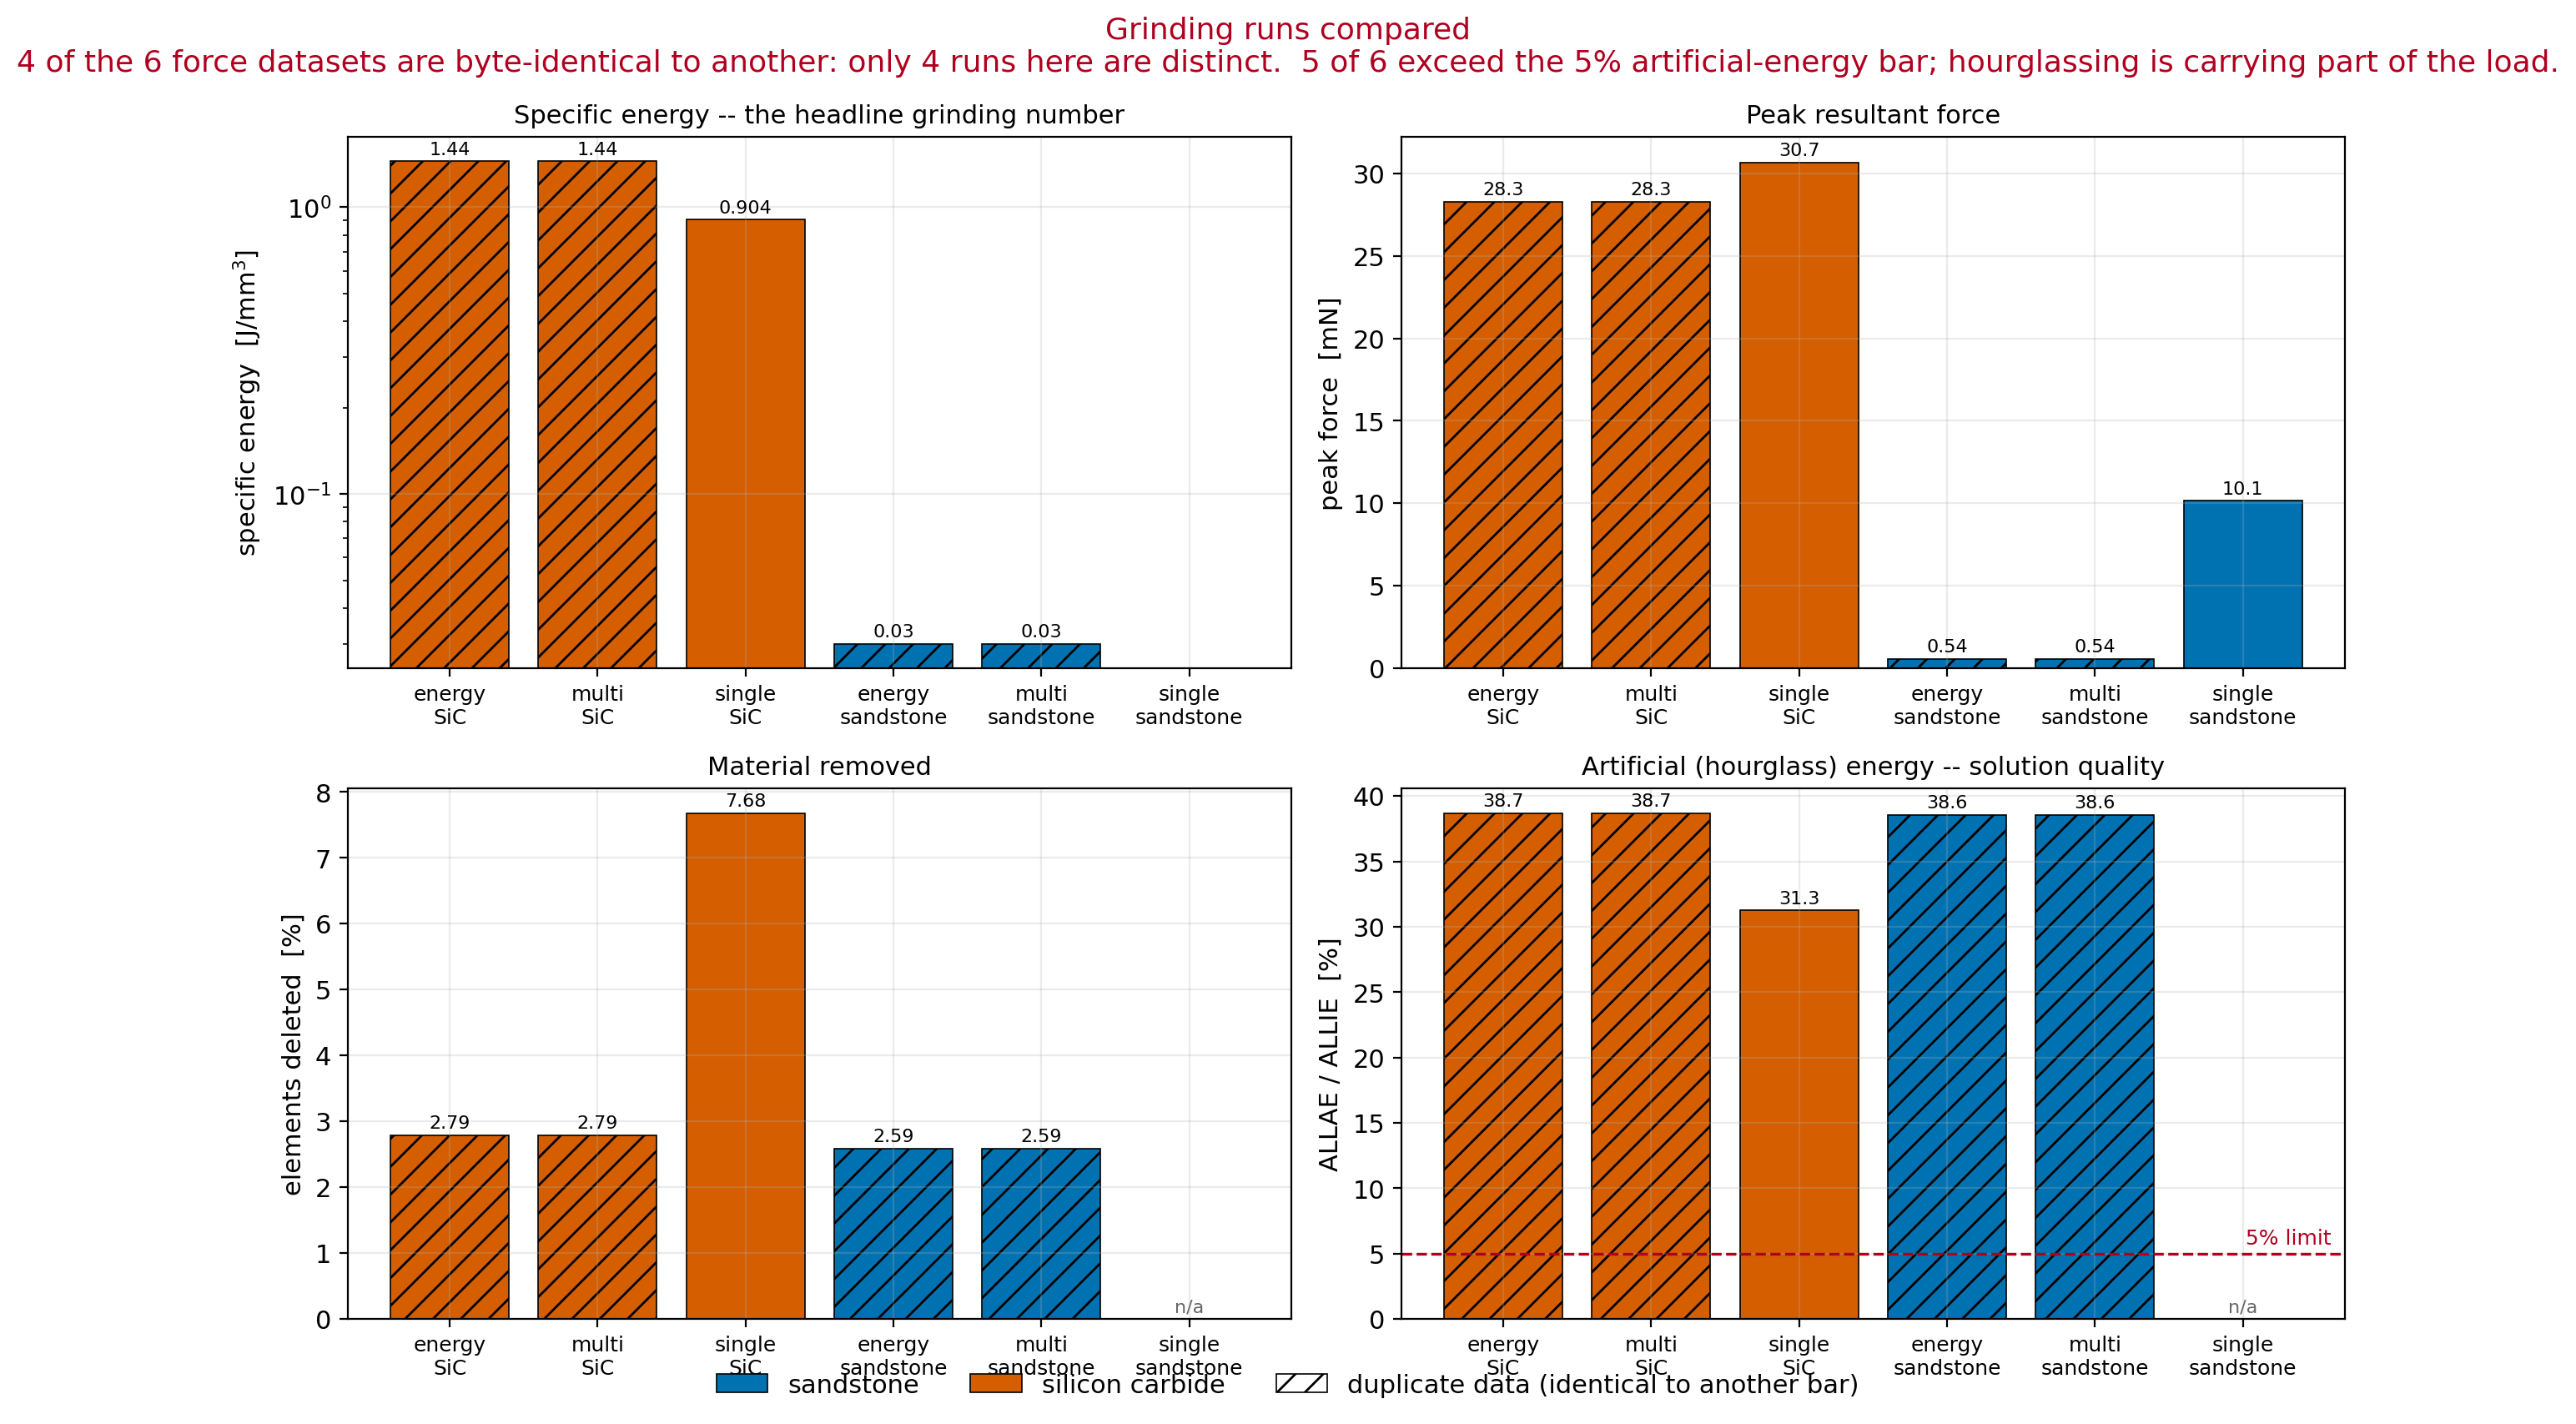

In [16]:
#@title 9b · The completed runs, plotted -- with the caveats drawn on
from IPython.display import Image, display

FIGDIR = os.path.join(WORK, "result_figures")
r = subprocess.run([sys.executable, os.path.join(WORK, "REPOST", "plots.py"),
                    ARCHIVE, "-o", FIGDIR],
                   capture_output=True, text=True, cwd=WORK)
print(r.stdout[-1500:] or r.stderr[-1500:])

# compare_all is the only cross-deck figure: specific energy, peak force,
# material removed and artificial-energy fraction, all six jobs side by side.
# It hatches the bars whose CSVs are byte-identical and draws the 5 % artificial
# energy line, so the two reasons these numbers are not yet quotable are ON the
# figure rather than in a footnote somebody skips.
_cmp = os.path.join(FIGDIR, "compare_all.png")
if os.path.exists(_cmp):
    display(Image(filename=_cmp))
else:
    print("compare_all.png was not produced -- see the log above")

---
# 10 · Summary

## What this notebook demonstrated, end to end

| # | stage | evidence shown |
|---|---|---|
| 1 | Calibration from instrument metadata | scale bar cross-check, agreeing to +0.40 % |
| 2 | Segmentation | all 12 stages drawn, including the keep/merge decision per boundary |
| 3 | Measurement | 25 descriptors, 6 distributions, border grains excluded and shown to be |
| 4 | 3-D reconstruction | every solid verified against closed-form geometry, worst case reported |
| 5 | Wheel assembly | one rigid body, workpiece seated tangent to the reachable grit |
| 6 | The hybrid law | $h(u)$ against $d_c$, with the transition station solved for |
| 7 | Deck | 56-constant card written 8 per line, verified in the file itself |
| 8 | Verification | independent gates re-derived the geometry from the written file |
| 9 | Results | archived runs re-checked, and the reasons they are not yet quotable |

## What is genuinely new here

1. **The switch is per material point, from that point's own chip thickness.** A
   conventional deck picks one constitutive law for the whole part and therefore cannot
   show a ductile-to-brittle transition at all.
2. **The kinematics are precomputed in Python and passed as material constants**, so
   the Fortran carries no process knowledge and stays verifiable on a single material
   point.
3. **The brittle branch is bit-identical to a published, independently verified JH-2
   implementation** when the switch is forced. The hybrid result is therefore bracketed
   between two known references.
4. **The geometry is measured, not idealised** — real concave outlines, seeded heights,
   guaranteed non-interpenetrating placement.

## What is still open, stated plainly

* **Johnson–Cook constants are placeholders** for both materials except $A$. Calibration
  against nanoindentation or single-scratch data is the next real step, and no force
  should be quoted before it.
* **$\lambda_c$ belongs to whichever $d_c$ form was used**; the two published forms
  differ by $(E/H)^{3/2}$, ~17× on sandstone.
* **$h$ is prescribed, not measured** — exact for one grit and a constant infeed, not
  valid for many interacting grits or for grits that wear during the run.
* **The switch is latched at the first increment** and does not migrate. The energy
  criterion in `vumat_grind2.for` removes that restriction — it triggers on accumulated
  plastic work, so a point starts ductile and turns brittle as the cut deepens under it.
* **The production runs are queued, not finished**, and the archived batch has the three
  data-integrity problems shown in section 9.

---

### Reproducing this

```bash
python _make_run_packages.py --all     # rebuild all 16 decks (deterministic, seeded)
python verify_all.py                   # 36 checks on the measurement pipeline
python verify_vumat_grind.py           # compiles the Fortran, checks against JH94
python -m semgrit.figures              # re-render every figure in this notebook
python REPOST/plots.py <dir>           # figures from a completed run's CSVs
```

The `.inp` decks are 88–155 MB each and are not in version control; the command above
rebuilds them byte-for-byte from the seed.